# 04 — Surrogate Model Training

Train an ensemble MLP surrogate on 7 VLM primitives:
CL_0, CL_alpha, CM_0, CM_alpha, CD0_wing, CD0_body, Cn_beta

## Steps
1. Load dataset
2. Feature augmentation (30 → ~52)
3. Train 5-model ensemble
4. Per-primitive accuracy analysis
5. Save trained model

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt

from src.surrogate.model import SurrogateModel, PRIMITIVE_TARGETS
from src.surrogate.features import augment_features
from src.surrogate.reconstruct import reconstruct_aero
from src.optimization.database import EvaluationDatabase
from src.aero.mission import MissionCondition, FeasibilityConfig

plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})

In [ ]:
%load_ext autoreload
%autoreload 2

## 1. Load Dataset

In [2]:
db = EvaluationDatabase.load('../data/eval_database_avl.json')
X_arr, results = db.to_arrays()
print(f'Loaded {len(db)} evaluations')
print(f'X shape: {X_arr.shape}')
n_success = sum(1 for r in results if r.get('success', True))
print(f'Successful VLM: {n_success}/{len(results)}')

Loaded 60000 evaluations
X shape: (60000, 30)
Successful VLM: 60000/60000


## 2. Train Surrogate

In [3]:
surrogate = SurrogateModel(n_ensemble=5)
success = surrogate.fit(X_arr, results, min_samples=30)

if success:
    print(f'Surrogate trained successfully!')
    print(f'Architecture: MLP {surrogate.architecture_str}')
    print(f'Targets: {PRIMITIVE_TARGETS}')
else:
    print('Training failed — not enough valid samples')

Surrogate trained successfully!
Architecture: MLP 256-128-64
Targets: ['CL_0', 'CL_alpha', 'CM_0', 'CM_alpha', 'CD0_wing', 'CD0_body', 'Cn_beta']


## 3. Accuracy Analysis — Parity Plots

Evaluating on 59004 clean samples (out of 60000 successful)


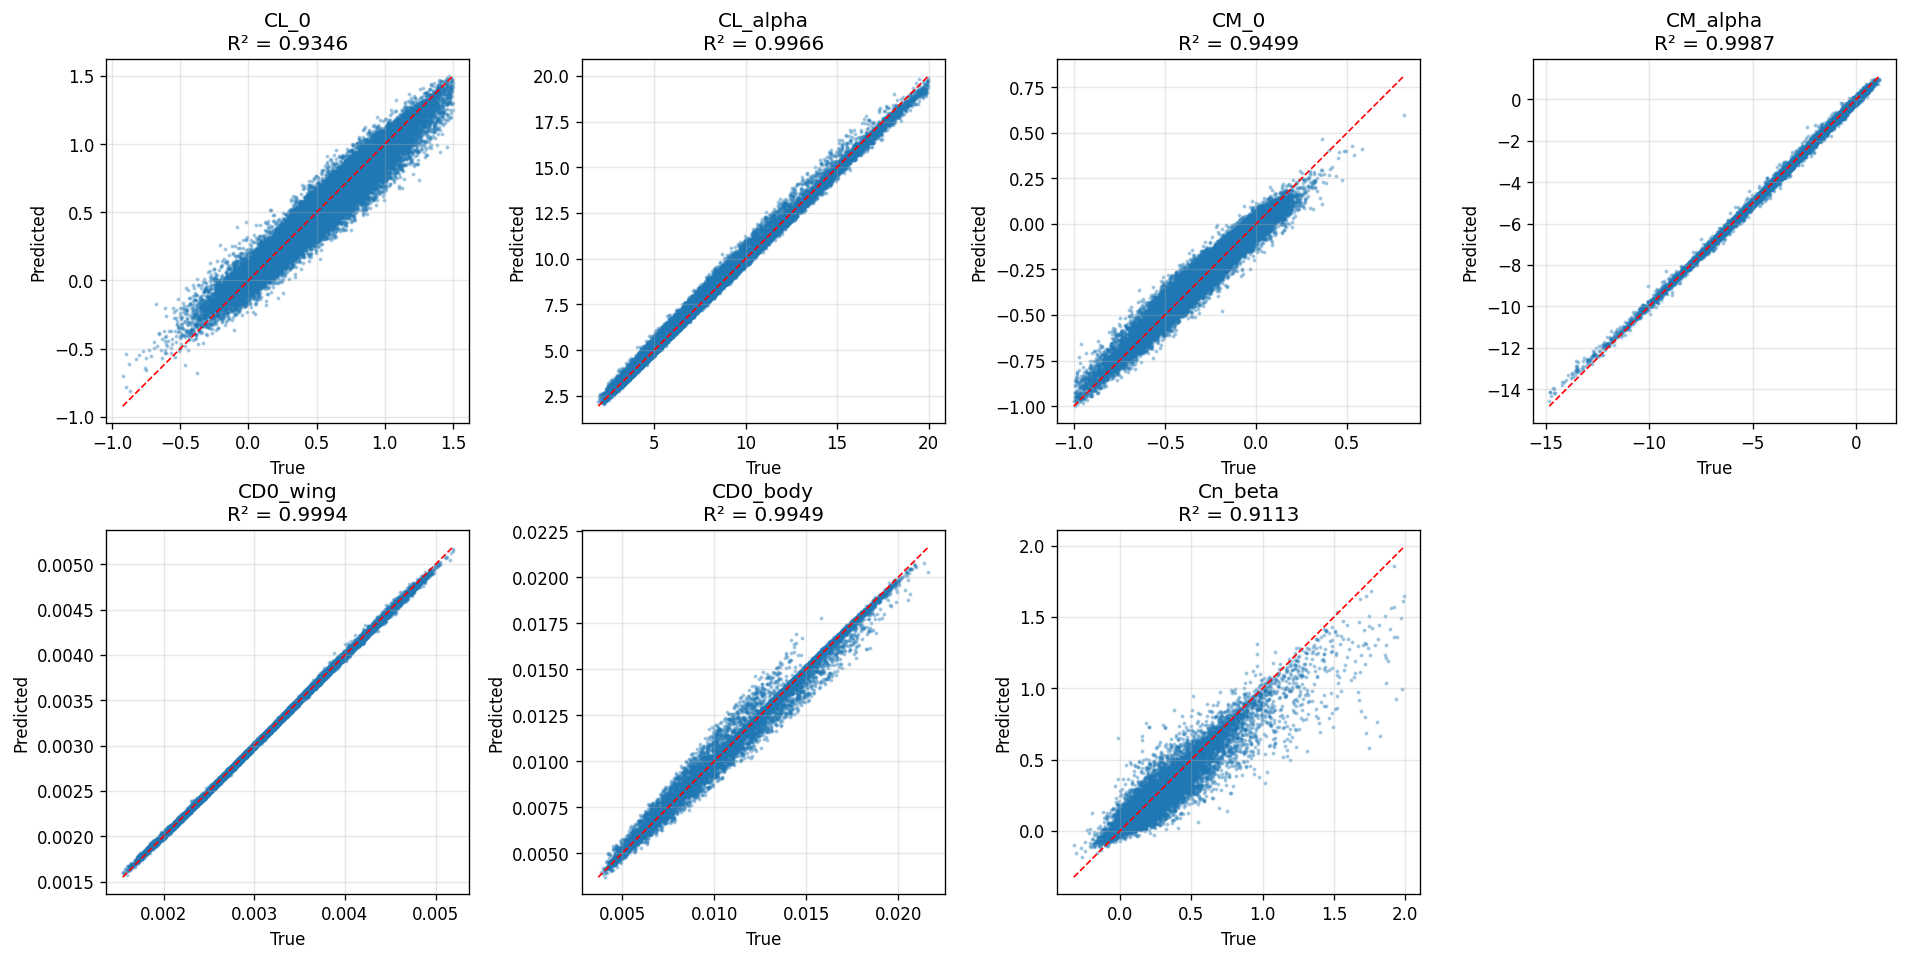

In [4]:
# Predict on CLEAN dataset only (filtered by _TARGET_CLIP)
if surrogate.is_trained:
    from src.surrogate.model import _TARGET_CLIP
    
    # Re-extract targets and apply same filter as fit()
    Y_rows, valid_idx = [], []
    for i, r in enumerate(results):
        if not r.get('success', True):
            continue
        alpha_eq_rad = np.radians(r.get('alpha_eq', 0.0))
        cl_alpha = r.get('CL_alpha', 0.0)
        cm_alpha = r.get('CM_alpha', 0.0)
        cl_0 = r.get('CL_0', None)
        if cl_0 is None:
            cl_0 = r.get('CL_required', 0.0) - cl_alpha * alpha_eq_rad
        cm_0 = r.get('CM_0', None)
        if cm_0 is None:
            cm_0 = r.get('CM', 0.0) - cm_alpha * alpha_eq_rad
        cd0_wing = r.get('CD0_wing', r.get('CD0', 0.008) * 0.6)
        cd0_body = r.get('CD0_body', r.get('CD0', 0.008) * 0.4)
        cn_beta = r.get('Cn_beta', 0.0)
        Y_rows.append([cl_0, cl_alpha, cm_0, cm_alpha, cd0_wing, cd0_body, cn_beta])
        valid_idx.append(i)
    
    Y_all = np.array(Y_rows)
    X_valid = X_arr[valid_idx]
    
    # Apply _TARGET_CLIP filter
    mask = np.ones(len(Y_all), dtype=bool)
    for j, key in enumerate(PRIMITIVE_TARGETS):
        lo, hi = _TARGET_CLIP[key]
        mask &= (Y_all[:, j] >= lo) & (Y_all[:, j] <= hi)
    
    X_clean = X_valid[mask]
    Y_clean = Y_all[mask]
    print(f'Evaluating on {mask.sum()} clean samples (out of {len(Y_all)} successful)')
    
    preds_clean = surrogate.predict(X_clean)
    
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    axes = axes.flat
    
    for i, key in enumerate(PRIMITIVE_TARGETS):
        ax = axes[i]
        y_true = Y_clean[:, i]
        y_pred = preds_clean[key]
        
        # R²
        ss_res = np.sum((y_true - y_pred)**2)
        ss_tot = np.sum((y_true - np.mean(y_true))**2)
        r2 = 1 - ss_res / ss_tot if ss_tot > 0 else 0
        
        ax.scatter(y_true, y_pred, s=2, alpha=0.3)
        lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
        ax.plot(lims, lims, 'r--', lw=1)
        ax.set_xlabel('True')
        ax.set_ylabel('Predicted')
        ax.set_title(f'{key}\nR² = {r2:.4f}')
        ax.set_aspect('equal')
        ax.grid(True, alpha=0.3)
    
    axes[7].set_visible(False)
    plt.tight_layout()
    plt.show()

## 4. Save Model

In [5]:
if surrogate.is_trained:
    surrogate.save('../models/surrogate_v2')
    print('Surrogate saved to models/surrogate_v2/')

Surrogate saved to models/surrogate_v2/
